In [5]:
import os
import sys
from pathlib import Path
os.environ["JAX_PLATFORMS"] = "cpu"

# Requires seaborn in addition to requirements.txt packages
import math
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


# Locate the outer repository regardless of where Jupyter was launched.
working_dir = Path.cwd().resolve()
repo_candidates = (
    working_dir,
    working_dir.parent,
    working_dir / "offline-rl-million-transitions",
    working_dir.parent / "offline-rl-million-transitions",
)
repo_root = next(
    (
        candidate
        for candidate in repo_candidates
        if (candidate / "final_returns").is_dir()
        and (candidate / "unifloral" / "evaluation.py").is_file()
    ),
    None,
)
if repo_root is None:
    raise FileNotFoundError(
        "Could not locate final_returns/. Launch Jupyter from this project,"
        " its unifloral/ directory, or its parent directory."
    )
sys.path.insert(0, str(repo_root / "unifloral"))
import evaluation

# --- Plot style configuration ---
plt.style.use("default")
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42
plt.rcParams["font.size"] = 14
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 12
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.5
plt.rcParams["figure.figsize"] = [12, 10]
plt.rcParams["figure.dpi"] = 300
plt.rcParams["savefig.dpi"] = 300

# --- Load data from the outer repository's final_returns folder ---
group_name = "debug"  # Set this to the wandb_group used by the sweep.
results_dir = repo_root / "final_returns" / group_name
print(f"Loading results from {results_dir}")
df = evaluation.load_results_dataframe(results_dir=str(results_dir))
if df.empty:
    raise FileNotFoundError(f"No readable .npz result files found in {results_dir}")
df.head()

Loading results from /home/phancoc3/RL-Research/offline-rl-million-transitions/final_returns/mujoco-halfcheetah-medium-v0


,final_returns,final_returns_mean,final_returns_std,final_scores,final_scores_mean,final_scores_std,algorithm,dataset,datetime,seed,...,exp_adv_clip,noise_clip,policy_noise,num_critic_updates_per_step,critic_bc_coef,actor_bc_coef,actor_ln,critic_ln,norm_obs,td3_alpha
0,"[15414.805271428664, 15338.299951397106, 15265...",15278.002048170709,790.3140757752897,"[126.4177043588738, 125.80148029701223, 125.21...",125.31580140785029,6.365708289563708,bc,mujoco/halfcheetah/medium-v0,2026-09-29 12:28:47,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"[14986.23911961594, 15348.593026201885, 15478....",14138.057569071969,3155.9184951074053,"[122.96575128244098, 125.88438747735773, 126.9...",116.13394036972741,25.41983894919864,bc,mujoco/halfcheetah/medium-v0,2026-09-29 12:29:07,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"[15310.435784846748, 15355.771832456843, 15213...",15262.625230070207,480.16289397590253,"[125.57704401094787, 125.94221029475034, 124.7...",125.19194642228213,3.8675471033776447,bc,mujoco/halfcheetah/medium-v0,2026-09-29 12:29:09,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"[8787.390216409927, 13957.803418657366, 14105....",10259.448867686933,4618.643347992932,"[73.03615359663296, 114.68205513233383, 115.87...",84.89308016087953,37.201584974954265,bc,mujoco/halfcheetah/medium-v0,2026-09-29 12:30:34,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"[6915.686438144798, 7242.249216508677, 5571.36...",3952.168529082231,2902.4455760974506,"[57.96022287222844, 60.59057382890932, 47.1321...",34.09010452531196,23.37820169234133,bc,mujoco/halfcheetah/medium-v0,2026-09-29 12:30:57,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# --- Define bandit evaluation and plotting ---
def plot_trial(final_scores, num_subsample=8, **kwargs):
    # Run multiple bandit trials and compute confidence intervals
    runs = np.stack(final_scores.values)
    res = evaluation.bootstrap_bandit_trials(
        runs, num_subsample=num_subsample, n_bootstraps=2000, num_repeats=500
    )

    # Plotting
    line = plt.semilogx(res["pulls"], res["estimated_bests_mean"], **kwargs)
    plt.fill_between(
        res["pulls"],
        res["estimated_bests_ci_low"],
        res["estimated_bests_ci_high"],
        alpha=0.3,
        color=line[0].get_color(),
    )

Running bandit evaluation... Done.


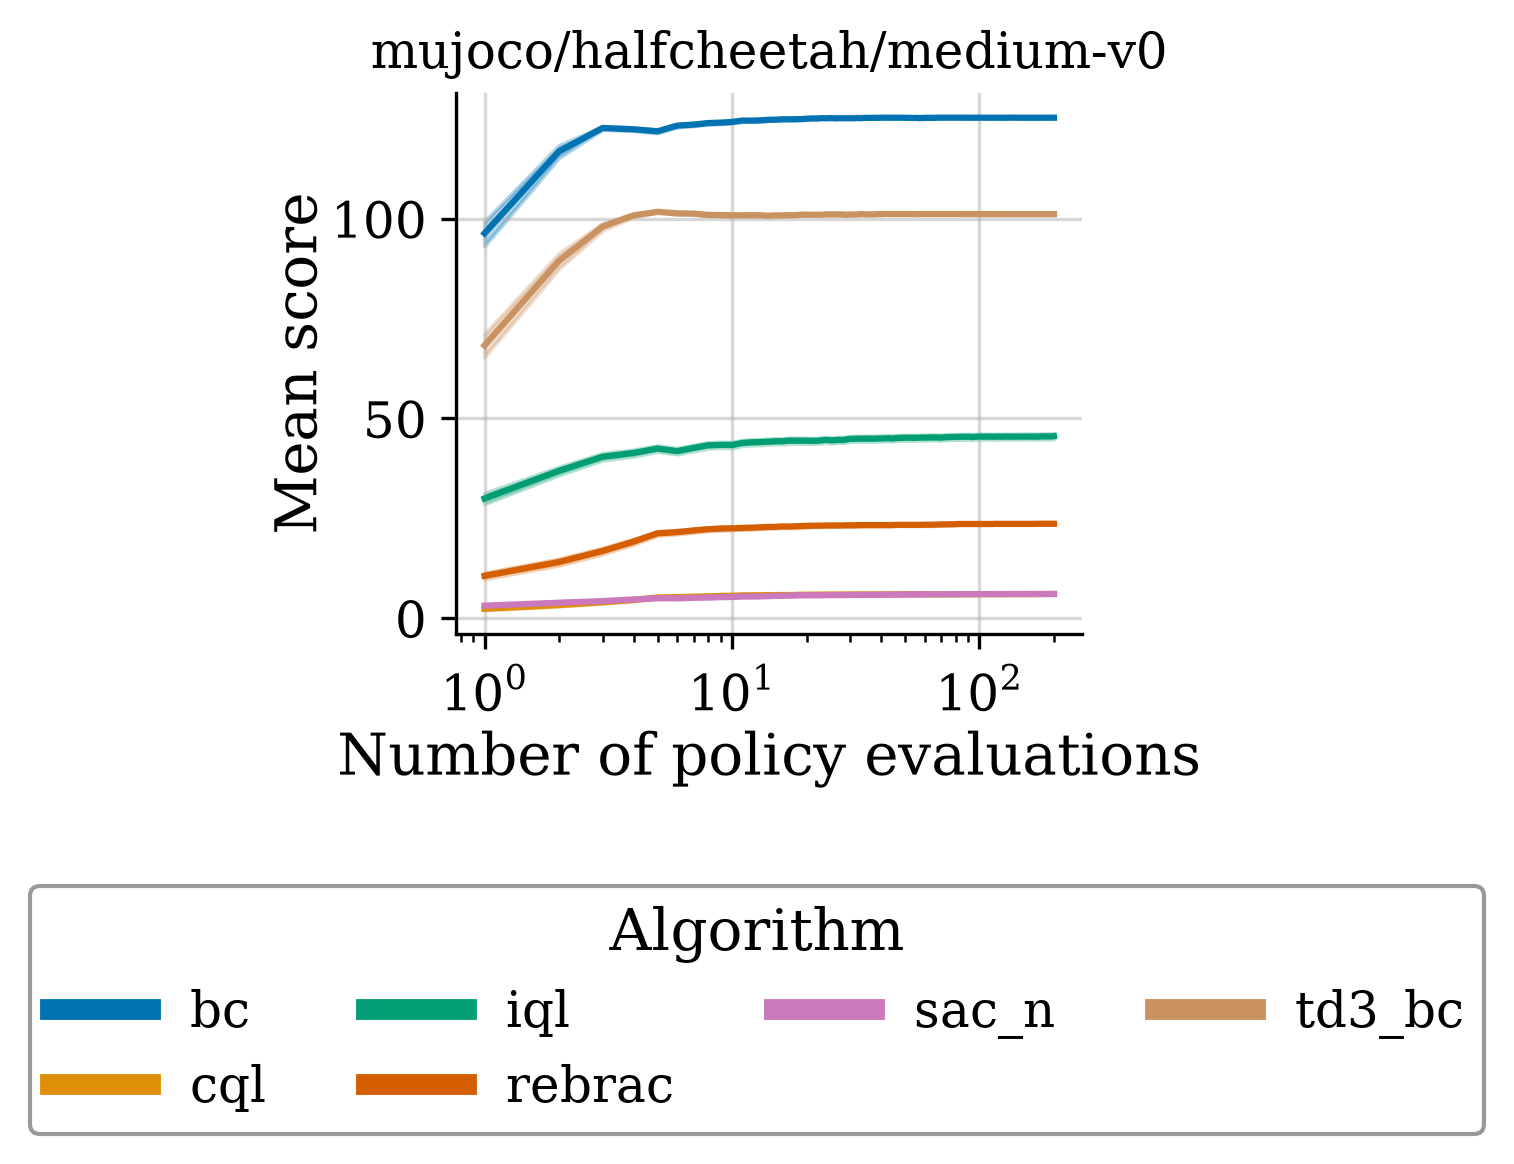

In [7]:
# --- Filter dataframe (optional) ---
plot_df = df
# E.g. plot_df = df.loc[df['algorithm'] != 'td3_bc']

# --- Run and plot bandit evaluation ---
ALGORITHM_COLOR_DICT = {algo: col for algo, col in zip(
    plot_df['algorithm'].unique(), sns.color_palette("colorblind"))}
plot_df["dataset"] = pd.Categorical(plot_df["dataset"])
num_datasets = len(plot_df["dataset"].unique())
num_algorithms = len(plot_df["algorithm"].unique())
g = sns.FacetGrid(
    plot_df,
    col="dataset",
    hue="algorithm",
    col_wrap=math.ceil(np.sqrt(num_datasets)),
    sharex=False,
    sharey=False,
    palette=ALGORITHM_COLOR_DICT,
)
print("Running bandit evaluation... ", end='')
g.map(plot_trial, "final_scores")
print("Done.")

# --- Format combined plot ---
# Remove individual x and y labels
for ax in g.axes.flat:
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title(ax.get_title().replace("dataset = ", ""))

# Add and format big axis for shared labels
fig = plt.gcf()
big_ax = fig.add_subplot(111, frameon=False)
big_ax.tick_params(labelcolor="none", top=False, bottom=False, left=False, right=False)
big_ax.grid(False)
plt.xlabel("Number of policy evaluations")
plt.ylabel("Mean score")

# Add and format legend
g.add_legend(title="Algorithm")
leg = g._legend
for line, text in zip(leg.get_lines(), leg.get_texts()):
    line.set_linewidth(5.0)
sns.move_legend(
    g,
    "upper center",
    bbox_to_anchor=(0.45, 0.0),
    ncol=1+(num_algorithms//2),
    frameon=True,
    edgecolor="gray",
    fancybox=True,
    shadow=False,
)

# Save the figure
plt.savefig("evaluation_plots.pdf", bbox_inches="tight")